# Week 6 · Notebook 1 — A Unified View of Metaheuristic Mechanisms

**Goals**
- Write every algorithm of the course as one loop: a *memory* $M_t$, a *generation* step that samples candidates from a distribution $P(\cdot \mid M_t)$, an evaluation, and a *selection/acceptance + memory update* step $M_{t+1} = U(M_t, X_t, f(X_t))$.
- Implement SA, TS, GA, PSO, ACO$_\mathbb{R}$, DE and CMA-ES as plug-ins of **one** generic ask–tell loop and validate each plug-in's defining mechanism against a known theoretical result.
- Formalise exploration vs exploitation with three measurable quantities and measure them for all algorithms on the same function.
- Reproduce the *metaphor critique*: show algebraically **and** numerically that harmony search is a $(\mu+1)$ evolution strategy.
- Demonstrate the *centre-bias* pitfall: an algorithm that "wins" on origin-centred benchmarks and collapses after a shift.

**Prerequisites:** Weeks 1–5 (local search, SA, TS, GA, PSO, ACO); Gaussian sampling; basic linear algebra.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import BENCHMARKS, shifted_rotated, PALETTE
from scipy import stats

## 1. One framework for all metaheuristics

Let $f:\mathcal{X}\to\mathbb{R}$ be minimised. A (black-box) metaheuristic is fully specified by four components:

| component | symbol | role |
|---|---|---|
| memory / state | $M_t$ | everything the algorithm carries between iterations (a point, a population, a tabu list, velocities, a pheromone archive, a mean + covariance) |
| generation | $X_t \sim P(\cdot \mid M_t)$ | stochastic *variation*: sample $\lambda$ candidates from a distribution parameterised by the memory |
| evaluation | $y_t = f(X_t)$ | the only access to the problem — counted against a budget |
| selection / update | $M_{t+1} = U(M_t, X_t, y_t)$ | *acceptance* (which candidates survive) and *learning* (how the distribution parameters move) |

This is the **ask–tell** interface popularised by CMA-ES implementations and it is also the skeleton of
*model-based search* (Zlochin, Birattari, Meuleau & Dorigo 2004) and of *estimation-of-distribution algorithms*.

```text
GENERIC-METAHEURISTIC(f, budget):
    M <- init()
    while evaluations < budget:
        X <- ask(M)                   # sample lambda candidates from P(. | M)
        y <- f(X)                     # counted evaluations
        M <- tell(M, X, y)            # selection / acceptance + memory update
    return best evaluated point
```

Every algorithm of the course is an instance:

| algorithm | memory $M_t$ | generation $P(\cdot\mid M_t)$ | selection / acceptance | memory update |
|---|---|---|---|---|
| SA (Kirkpatrick et al. 1983) | current $x$, temperature $T$ | $x + \sigma_t \mathcal{N}(0,I)$ | Metropolis: accept w.p. $\min(1, e^{-\Delta/T})$ | $x$ if accepted; $T,\sigma$ by schedule |
| TS (Glover 1986) | current $x$, tabu list of last $L$ states | $k$ neighbours $x + \sigma_t\mathcal{N}(0,I)$ | best **admissible** neighbour (non-tabu or aspirated), even if worse | push $x$ into FIFO tabu list |
| GA (Holland 1975) | population $P$ | tournament $\to$ SBX $\to$ polynomial mutation | generational + 1 elite | $P \leftarrow$ elite $\cup$ offspring |
| PSO (Kennedy & Eberhart 1995) | positions, velocities, personal bests | deterministic given $(r_1,r_2)$: $v \leftarrow wv + c_1r_1(p-x)+c_2r_2(g-x)$ | none on positions; personal best is elitist | $p_i \leftarrow x_i$ if better |
| ACO$_\mathbb{R}$ (Socha & Dorigo 2008) | archive of $k$ best (the "pheromone") | Gaussian mixture centred at archive members, rank weights | truncation to $k$ best ($(k+m)$ elitist) | archive $\leftarrow$ best $k$ |
| DE (Storn & Price 1997) | population | $v = x_{r_1} + F(x_{r_2}-x_{r_3})$, binomial crossover | one-to-one greedy (child vs parent) | replace parent if not worse |
| CMA-ES (Hansen & Ostermeier 2001) | $m, \sigma, C, p_\sigma, p_c$ | $\mathcal{N}(m, \sigma^2 C)$ | $(\mu,\lambda)$ truncation, **non-elitist** | weighted mean, CSA for $\sigma$, rank-one + rank-$\mu$ for $C$ |

Seen this way, algorithms differ only in *which* distribution family they sample from, *what* memory they keep and
*how greedy* the acceptance is — not in the natural phenomenon that inspired them.

### Implementation
The base class and the single generic loop. `optimize` is the **only** loop in this notebook; the algorithms below
implement just `ask` and `tell`. Evaluations are counted by `BudgetedObjective`; a last batch that would overrun
the budget is truncated so that every algorithm spends *exactly* the same number of evaluations.

In [2]:
# ---------------------------------------------------------------------------
# Ask-tell core: every algorithm is (memory M, ask = sample from P(.|M),
# tell = selection/acceptance + memory update). One generic loop drives all.
# ---------------------------------------------------------------------------
from utils import BudgetedObjective, BudgetExhausted


class AskTell:
    """Base class. Subclasses keep their memory in attributes and implement
    ask() -> (n, d) candidates and tell(X, y) -> None.
    `working_fitness()` returns the fitness values of the current working set
    (the states the next generation is derived from), used for diagnostics."""
    name = "base"

    def __init__(self, d, lo, hi, budget, rng):
        self.d, self.lo, self.hi, self.budget, self.rng = d, lo, hi, budget, rng
        self.span = (hi - lo) if lo is not None else 1.0
        self.n_told = 0

    def clip(self, X):
        return X if self.lo is None else np.clip(X, self.lo, self.hi)

    def uniform(self, n):
        return self.rng.uniform(self.lo, self.hi, (n, self.d))

    def progress(self):
        return min(1.0, self.n_told / self.budget)

    def working_fitness(self):
        return np.array([np.nan])


def distinct_indices(rng, n, k, n_pool=None, exclude=None):
    """For each row i < n: k distinct indices from range(n_pool), all different from i
    (and from exclude[i] if given), in uniformly random order (argsort of random keys)."""
    n_pool = n if n_pool is None else n_pool
    keys = rng.random((n, n_pool))
    keys[np.arange(n), np.arange(n)] = np.inf
    if exclude is not None:
        keys[np.arange(n), exclude] = np.inf
    return np.argsort(keys, axis=1)[:, :k]


def optimize(opt, f, budget, callback=None):
    """The single generic loop: ask -> evaluate (counted) -> tell.
    A final batch that would overrun the budget is truncated, so every
    algorithm spends exactly `budget` evaluations."""
    obj = BudgetedObjective(f, budget)
    while obj.remaining > 0:
        X = opt.ask()
        if len(X) > obj.remaining:
            obj(X[: obj.remaining])
            break
        y = obj(X)
        opt.tell(X, y)
        opt.n_told += len(y)
        if callback is not None:
            callback(opt, X, y, obj)
    return obj

class RandomSearch(AskTell):
    name = "RS"

    def ask(self):
        return self.uniform(20)

    def tell(self, X, y):
        pass

### Trajectory methods: SA and TS
Both keep a single current state. SA's acceptance is stochastic and *fitness-proportional*; TS's acceptance is
deterministic (best admissible neighbour) and its non-greediness comes from *memory* (the tabu list) rather than
randomness. The TS here is a continuous variant in the spirit of Chelouah & Siarry (2000): a neighbour is tabu
if it lies within radius $\rho$ of one of the last $L$ visited states.

In [3]:
class SA(AskTell):
    """Simulated annealing: Gaussian proposal around the single current state,
    Metropolis acceptance; T and step size decay geometrically with the budget.
    T0 is calibrated so that the mean worsening seen in a short initial random
    walk is accepted with probability 1/2 (a common data-driven rule)."""
    name = "SA"

    def __init__(self, d, lo, hi, budget, rng, step0=0.1, step_end=1e-5, T_ratio=1e-8, n_cal=50, T0=None):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx = None
        self.step0, self.step_end, self.T_ratio, self.n_cal = step0, step_end, T_ratio, n_cal
        self.T0 = T0
        self.cal = []
        self.log = []  # (delta, T, accepted) for worsening proposals

    def sched(self):
        p = self.progress()
        sig = self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)
        return sig, (self.T0 * self.T_ratio ** p if self.T0 is not None else np.inf)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        sig, _ = self.sched()
        return self.clip(self.x + sig * self.rng.standard_normal(self.d))[None]

    def tell(self, X, y):
        if self.fx is None:
            self.fx = y[0]
            return
        delta = y[0] - self.fx
        if self.T0 is None:  # calibration random walk
            if delta > 0:
                self.cal.append(delta)
            self.x, self.fx = X[0], y[0]
            if len(self.cal) >= self.n_cal:
                self.T0 = np.mean(self.cal) / np.log(2.0)
            return
        _, T = self.sched()
        if delta <= 0:
            acc = True
        else:
            acc = self.rng.random() < np.exp(-delta / T)
            self.log.append((delta, T, acc))
        if acc:
            self.x, self.fx = X[0], y[0]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

class TS(AskTell):
    """Continuous tabu search: sample k Gaussian neighbours, forbid those within
    radius rho of the last L visited states (tabu list = short-term memory),
    move to the best admissible neighbour even if it is worse; aspiration:
    a tabu neighbour is admissible if it beats the best-so-far."""
    name = "TS"

    def __init__(self, d, lo, hi, budget, rng, k=8, L=20, step0=0.1, step_end=1e-5, rho_factor=0.5):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx, self.k, self.L = None, k, L
        self.step0, self.step_end, self.rho_factor = step0, step_end, rho_factor
        self.tabu = []
        self.best = np.inf
        self.log = []  # (distance to tabu list, rho, new best?, fallback?, worsening?)

    def sigma(self):
        p = self.progress()
        return self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        return self.clip(self.x + self.sigma() * self.rng.standard_normal((self.k, self.d)))

    def tell(self, X, y):
        if self.fx is None:
            self.fx = self.best = y[0]
            self.tabu.append(self.x.copy())
            return
        sig = self.sigma()
        rho = self.rho_factor * sig * np.sqrt(self.d)
        T = np.array(self.tabu)
        dist = np.sqrt(((X[:, None, :] - T[None]) ** 2).sum(-1)).min(1)
        admissible = (dist >= rho) | (y < self.best)
        fallback = not admissible.any()
        if fallback:  # every neighbour tabu and none aspirated: take the best one anyway
            admissible[:] = True
        idx = np.flatnonzero(admissible)
        j = idx[np.argmin(y[idx])]
        self.log.append((dist[j], rho, y[j] < self.best, fallback, y[j] > self.fx))
        self.x, self.fx = X[j].copy(), y[j]
        self.best = min(self.best, y[j])
        self.tabu.append(self.x.copy())
        self.tabu = self.tabu[-self.L:]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

### Population methods: GA, PSO, ACO$_\mathbb{R}$, DE, CMA-ES
SBX (Deb & Agrawal 1995) with spread factor $\beta$ has the property that the parents' midpoint is preserved,
$\tfrac12(c_1+c_2)=\tfrac12(p_1+p_2)$. ACO$_\mathbb{R}$ uses rank weights
$\omega_l = \frac{1}{qk\sqrt{2\pi}}\exp\!\big(-\frac{(l-1)^2}{2q^2k^2}\big)$ and per-coordinate standard deviations
$\sigma_l^i = \xi \sum_{e} |s_e^i - s_l^i|/(k-1)$. CMA-ES is given in compact form here; Notebook 2 derives it.

In [4]:
def sbx_pm(P1, P2, lo, hi, rng, pc=0.9, eta_c=15.0, pm=None, eta_m=20.0):
    """Simulated binary crossover (Deb & Agrawal 1995) + polynomial mutation
    (Deb & Goyal 1996), vectorised over pairs; box [lo, hi]."""
    n, d = P1.shape
    pm = 1.0 / d if pm is None else pm
    u = rng.random((n, d))
    beta = np.where(u <= 0.5, (2 * u) ** (1 / (eta_c + 1)), (1 / (2 * (1 - u))) ** (1 / (eta_c + 1)))
    cross = (rng.random((n, 1)) < pc) & (rng.random((n, d)) < 0.5)
    beta = np.where(cross, beta, 1.0)
    C1 = 0.5 * ((1 + beta) * P1 + (1 - beta) * P2)
    C2 = 0.5 * ((1 - beta) * P1 + (1 + beta) * P2)
    swap = cross & (rng.random((n, d)) < 0.5)  # exchange crossed variables w.p. 1/2 (as in Deb's code)
    C = np.vstack([np.where(swap, C2, C1), np.where(swap, C1, C2)])
    u = rng.random(C.shape)
    delta = np.where(u < 0.5, (2 * u) ** (1 / (eta_m + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta_m + 1)))
    mut = rng.random(C.shape) < pm
    C = C + mut * delta * (hi - lo)
    return np.clip(C, lo, hi)


class GA(AskTell):
    """Real-coded generational GA: binary tournament selection, SBX crossover,
    polynomial mutation, elitism of size 1."""
    name = "GA"

    def __init__(self, d, lo, hi, budget, rng, n=50, pc=0.9, pm=None, tour=2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.pc, self.pm, self.tour = n, pc, pm, tour
        self.P, self.fP = None, None

    def select(self, k):
        c = self.rng.integers(0, self.n, (k, self.tour))
        return c[np.arange(k), np.argmin(self.fP[c], axis=1)]

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        m = self.n // 2 + 1
        a, b = self.select(m), self.select(m)
        C = sbx_pm(self.P[a], self.P[b], self.lo, self.hi, self.rng, pc=self.pc, pm=self.pm)
        return C[: self.n - 1]

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        e = np.argmin(self.fP)
        self.P = np.vstack([self.P[e], X])
        self.fP = np.concatenate([[self.fP[e]], y])

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class PSO(AskTell):
    """Global-best PSO with inertia weight (Shi & Eberhart 1998); defaults
    w = 0.7298, c1 = c2 = 1.49618 are Clerc & Kennedy's (2002) constriction
    coefficients rewritten in inertia form. Velocity clamped to vmax."""
    name = "PSO"

    def __init__(self, d, lo, hi, budget, rng, n=40, w=0.7298, c1=1.49618, c2=1.49618, vmax=0.2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.w, self.c1, self.c2 = n, w, c1, c2
        self.vmax = vmax * self.span
        self.X = self.uniform(n)
        self.V = rng.uniform(-1, 1, (n, d)) * 0.1 * self.span
        self.Pb, self.fPb, self.fX = None, None, None

    def ask(self):
        if self.Pb is None:
            return self.X
        g = self.Pb[np.argmin(self.fPb)]
        r1, r2 = self.rng.random((2, self.n, self.d))
        self.V = self.w * self.V + self.c1 * r1 * (self.Pb - self.X) + self.c2 * r2 * (g - self.X)
        self.V = np.clip(self.V, -self.vmax, self.vmax)
        self.X = self.clip(self.X + self.V)
        return self.X

    def tell(self, X, y):
        if self.Pb is None:
            self.Pb, self.fPb = X.copy(), y.copy()
        else:
            imp = y < self.fPb
            self.Pb[imp], self.fPb[imp] = X[imp], y[imp]
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

class ACOR(AskTell):
    """ACO for continuous domains (Socha & Dorigo 2008). Memory = archive of the
    k best solutions (the 'pheromone'); each ant picks a guide solution l with
    probability proportional to a Gaussian rank weight and samples each
    coordinate from N(s_l, sigma_l), sigma_l = xi * mean |s_e - s_l|."""
    name = "ACO_R"

    def __init__(self, d, lo, hi, budget, rng, k=50, m=2, q=0.1, xi=0.85):
        super().__init__(d, lo, hi, budget, rng)
        self.k, self.m, self.q, self.xi = k, m, q, xi
        r = np.arange(1, k + 1)
        w = np.exp(-((r - 1) ** 2) / (2 * (q * k) ** 2)) / (q * k * np.sqrt(2 * np.pi))
        self.p = w / w.sum()
        self.cdf = np.cumsum(self.p)
        self.S, self.fS = None, None
        self.last_guides = None

    def ask(self):
        if self.S is None:
            return self.uniform(self.k)
        l = np.minimum(np.searchsorted(self.cdf, self.rng.random(self.m)), self.k - 1)
        self.last_guides = l
        sig = self.xi * np.abs(self.S[None, :, :] - self.S[l][:, None, :]).sum(1) / (self.k - 1)
        return self.clip(self.S[l] + sig * self.rng.standard_normal((self.m, self.d)))

    def tell(self, X, y):
        S = X if self.S is None else np.vstack([self.S, X])
        fS = y if self.fS is None else np.concatenate([self.fS, y])
        o = np.argsort(fS, kind="stable")[: self.k]
        self.S, self.fS = S[o], fS[o]

    def working_fitness(self):
        return self.fS if self.fS is not None else np.array([np.nan])

class DE(AskTell):
    """DE/rand/1/bin (Storn & Price 1997) with one-to-one greedy replacement."""
    name = "DE"

    def __init__(self, d, lo, hi, budget, rng, n=50, F=0.5, CR=0.9):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.F, self.CR = n, F, CR
        self.P, self.fP = None, None

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d = self.n, self.d
        idx = distinct_indices(self.rng, n, 3)
        V = self.P[idx[:, 0]] + self.F * (self.P[idx[:, 1]] - self.P[idx[:, 2]])
        mask = self.rng.random((n, d)) < self.CR
        mask[np.arange(n), self.rng.integers(0, d, n)] = True
        self.mask = mask
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        imp = y <= self.fP
        self.P[imp], self.fP[imp] = X[imp], y[imp]

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class CMAES(AskTell):
    """(mu/mu_w, lambda)-CMA-ES with the default strategy parameters of Hansen's
    tutorial (arXiv:1604.00772v1, 2016, Table 1): weighted recombination, cumulative
    step-size adaptation (CSA), rank-one + rank-mu covariance update.
    Deviation: only the mu positive weights are used (w_i = 0 for i > mu), as in
    the tutorial's reference code (Appendix C); Table 1's default also has negative
    weights ("active" CMA). All other constants (c_sigma, d_sigma, c_c, c_1, c_mu,
    h_sigma) are exactly the formulas of the 2016 tutorial."""
    name = "CMA-ES"

    def __init__(self, d, lo, hi, budget, rng, m0=None, sigma0=0.3, lam=None):
        super().__init__(d, lo, hi, budget, rng)
        n = d
        self.m = (self.uniform(1)[0] if lo is not None else np.zeros(n)) if m0 is None else np.array(m0, float)
        self.sigma = sigma0 * self.span
        self.lam = lam or 4 + int(3 * np.log(n))
        self.mu = self.lam // 2
        wp = np.log((self.lam + 1) / 2) - np.log(np.arange(1, self.mu + 1))
        self.w = wp / wp.sum()
        self.mueff = 1 / np.sum(self.w**2)
        self.cs = (self.mueff + 2) / (n + self.mueff + 5)
        self.ds = 1 + 2 * max(0, np.sqrt((self.mueff - 1) / (n + 1)) - 1) + self.cs
        self.cc = (4 + self.mueff / n) / (n + 4 + 2 * self.mueff / n)
        self.c1 = 2 / ((n + 1.3) ** 2 + self.mueff)
        self.cmu = min(1 - self.c1, 2 * (self.mueff - 2 + 1 / self.mueff) / ((n + 2) ** 2 + self.mueff))
        self.chiN = np.sqrt(n) * (1 - 1 / (4 * n) + 1 / (21 * n**2))
        self.ps, self.pc = np.zeros(n), np.zeros(n)
        self.C, self.B, self.D = np.eye(n), np.eye(n), np.ones(n)
        self.g = 0
        self.fX = None

    def ask(self):
        Z = self.rng.standard_normal((self.lam, self.d))
        return self.clip(self.m + self.sigma * (Z * self.D) @ self.B.T)

    def tell(self, X, y):
        n = self.d
        o = np.argsort(y)
        Y = (X[o[: self.mu]] - self.m) / self.sigma
        yw = self.w @ Y
        self.m = self.m + self.sigma * yw
        Cinvsqrt = (self.B / self.D) @ self.B.T
        self.ps = (1 - self.cs) * self.ps + np.sqrt(self.cs * (2 - self.cs) * self.mueff) * Cinvsqrt @ yw
        self.g += 1
        hs = np.linalg.norm(self.ps) / np.sqrt(1 - (1 - self.cs) ** (2 * self.g)) < (1.4 + 2 / (n + 1)) * self.chiN
        self.pc = (1 - self.cc) * self.pc + hs * np.sqrt(self.cc * (2 - self.cc) * self.mueff) * yw
        dh = (1 - hs) * self.cc * (2 - self.cc)
        self.C = ((1 - self.c1 - self.cmu + self.c1 * dh) * self.C + self.c1 * np.outer(self.pc, self.pc)
                  + self.cmu * (Y.T * self.w) @ Y)
        self.sigma *= np.exp(self.cs / self.ds * (np.linalg.norm(self.ps) / self.chiN - 1))
        self.C = (self.C + self.C.T) / 2
        ev, self.B = np.linalg.eigh(self.C)
        self.D = np.sqrt(np.maximum(ev, 1e-30))
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

## 2. Validating each plug-in against a known result

A generic loop is only useful if each component really implements its mechanism. Instead of comparing the code with
itself we test each mechanism against an **independent theoretical prediction**:

| plug-in | mechanism | independent prediction |
|---|---|---|
| SA | Metropolis rule | $\Pr[\text{accept}\mid\Delta\gt 0] = e^{-\Delta/T}$ $\Rightarrow$ $Z = (\sum a_i - \sum p_i)/\sqrt{\sum p_i(1-p_i)} \approx \mathcal{N}(0,1)$ |
| TS | tabu + aspiration | every move goes to the best neighbour that is non-tabu (distance to the last $L$ states $\ge \rho$) **or** a new best-so-far — audited by an external observer |
| GA | tournament of size $s$ | if a fraction $P$ of the population is best, a selected parent is best w.p. $1-(1-P)^s$ |
| PSO | inertia/acceleration | order-2 stability iff $c_1+c_2 \lt 24(1-w^2)/(7-5w)$ (Poli 2009) |
| ACO$_\mathbb{R}$ | guide selection | guide rank $l$ chosen w.p. $\omega_l/\sum\omega$ |
| DE | binomial crossover | #coordinates taken from the mutant $= 1 + \mathrm{Bin}(d-1, CR)$, mean $1+(d-1)CR$ |
| all seven | full loop | converge to the known optimum $f^{\ast}=0$ of the sphere |

In [5]:
d = 10
sph = BENCHMARKS["sphere"]
# --- SA: Metropolis acceptance test
sa = SA(d, sph.lower, sph.upper, 20000, np.random.default_rng(1))
optimize(sa, BENCHMARKS["rastrigin"].f, 20000)
L = np.array(sa.log)
p = np.exp(-L[:, 0] / L[:, 1])
Z = (L[:, 2].sum() - p.sum()) / np.sqrt((p * (1 - p)).sum())
print(f"SA: {len(L)} worsening proposals, accepted {int(L[:, 2].sum())}, predicted {p.sum():.1f}, Z = {Z:.2f}")
check_true(abs(Z) < 3, "SA acceptance frequencies match exp(-Delta/T) (|Z| < 3)")

# --- TS: audit every move from OUTSIDE the plug-in (its internal log is not used): an observer keeps its own
# list of visited states and best-so-far, and checks that the new state is the best admissible neighbour
class TSAudit:
    """Callback that re-derives the TS move rule from observations only (X, y and the new current state)."""
    def __init__(self):
        self.visited, self.best, self.fx, self.rows = [], np.inf, np.inf, []

    def __call__(self, opt, X, y, obj):
        if not self.visited:                                   # first call: the initial point was evaluated
            self.visited.append(opt.x.copy()); self.best = self.fx = opt.fx; return
        p = min(1.0, (opt.n_told - len(y)) / opt.budget)       # progress at the time of this tell
        rho = opt.rho_factor * opt.span * opt.step0 * (opt.step_end / opt.step0) ** p   # rho = factor * sigma * sqrt(d)
        T = np.array(self.visited[-opt.L:])
        dist = np.sqrt(((X[:, None, :] - T[None]) ** 2).sum(-1)).min(1)
        adm = (dist >= rho) | (y < self.best)                  # non-tabu, or tabu but aspirated
        forced = not adm.any()
        if forced:
            adm[:] = True
        j = np.flatnonzero(adm)[np.argmin(y[adm])]
        self.rows.append((opt.fx == y[j] and np.array_equal(opt.x, X[j]),   # moved to the best admissible neighbour
                          dist[j] < rho and not forced,                     # ... by aspiration
                          forced, y[j] > self.fx))                          # forced move / worsening move
        self.visited.append(opt.x.copy()); self.best = min(self.best, opt.fx); self.fx = opt.fx

ts, audit = TS(d, sph.lower, sph.upper, 20000, np.random.default_rng(2)), TSAudit()
optimize(ts, BENCHMARKS["rastrigin"].f, 20000, callback=audit)
A_ = np.array(audit.rows)
print(f"TS: {len(A_)} moves, {int(A_[:, 1].sum())} by aspiration, {int(A_[:, 2].sum())} forced (all neighbours tabu), "
      f"{A_[:, 3].mean():.1%} worsening moves")
check_true(A_[:, 0].all(), "TS (external audit): every move goes to the best non-tabu-or-aspirated neighbour")

# --- GA: tournament selection probability
for s_t, P_best in [(2, 0.1), (3, 0.1), (2, 0.4)]:
    ga = GA(d, sph.lower, sph.upper, 1000, np.random.default_rng(3), n=50, tour=s_t)
    ga.fP = np.where(np.arange(50) < int(P_best * 50), 0.0, 1.0 + np.arange(50))
    frac = np.mean(ga.fP[ga.select(200000)] == 0.0)
    check_close(frac, 1 - (1 - P_best) ** s_t, f"GA tournament s={s_t}, P={P_best}: Pr[select best]", atol=4e-3)

SA: 18494 worsening proposals, accepted 1388, predicted 1338.6, Z = 1.82
[PASS] SA acceptance frequencies match exp(-Delta/T) (|Z| < 3)


TS: 2499 moves, 7 by aspiration, 0 forced (all neighbours tabu), 51.7% worsening moves
[PASS] TS (external audit): every move goes to the best non-tabu-or-aspirated neighbour
[PASS] GA tournament s=2, P=0.1: Pr[select best]: got 0.19152, expected 0.19
[PASS] GA tournament s=3, P=0.1: Pr[select best]: got 0.271295, expected 0.271
[PASS] GA tournament s=2, P=0.4: Pr[select best]: got 0.640355, expected 0.64


In [6]:
# --- PSO: order-2 stability boundary, derived from the second-moment recursion of a stagnant particle
def pso_second_moment_radius(w, csum):
    """x_{t+1} = (1+w-phi) x_t - w x_{t-1}, phi = c1 r1 + c2 r2 (c1 = c2 = csum/2, p = g = 0).
    The vector (E x_t^2, E x_t x_{t-1}, E x_{t-1}^2) evolves linearly; return its spectral radius."""
    Ephi, Vphi = csum / 2, 2 * (csum / 2) ** 2 / 12
    Ea = 1 + w - Ephi
    M = np.array([[Ea**2 + Vphi, -2 * w * Ea, w**2], [Ea, -w, 0.0], [1.0, 0.0, 0.0]])
    return np.max(np.abs(np.linalg.eigvals(M)))

from scipy.optimize import brentq
for w in [0.0, 0.4, 0.7298, 0.9]:
    c_poli = 24 * (1 - w**2) / (7 - 5 * w)
    c_num = brentq(lambda c: pso_second_moment_radius(w, c) - 1, 1e-3, 1.5 * c_poli)
    check_close(c_num, c_poli, f"PSO stability boundary c1+c2 at w={w}")

def pso_moment_matrix(w, csum):
    Ephi, Vphi = csum / 2, 2 * (csum / 2) ** 2 / 12
    Ea = 1 + w - Ephi
    return np.array([[Ea**2 + Vphi, -2 * w * Ea, w**2], [Ea, -w, 0.0], [1.0, 0.0, 0.0]])

def stagnant_particles(w, csum, T, n=400000, seed=0):
    """Monte Carlo of n independent 1-D stagnant particles (p = g = 0), x_0, x_{-1} ~ N(0,1)."""
    r = np.random.default_rng(seed)
    x_prev, x = r.standard_normal(n), r.standard_normal(n)
    for _ in range(T):
        phi = csum / 2 * (r.random(n) + r.random(n))
        x_prev, x = x, (1 + w - phi) * x - w * x_prev
    return x**2

for csum in [2 * 1.49618, 4.0]:
    x2 = stagnant_particles(0.7298, csum, T=10)
    exact = (np.linalg.matrix_power(pso_moment_matrix(0.7298, csum), 10) @ np.array([1.0, 0.0, 1.0]))[0]
    check_close(x2.mean(), exact, f"PSO c1+c2={csum:.3f}: Monte Carlo E[x_10^2] vs moment recursion",
                atol=4 * x2.std() / np.sqrt(len(x2)), rtol=0)
x2_long = stagnant_particles(0.7298, 4.0, T=200, n=20000)
pred_long = (np.linalg.matrix_power(pso_moment_matrix(0.7298, 4.0), 200) @ np.array([1.0, 0.0, 1.0]))[0]
print(f"c1+c2=4, t=200: predicted E[x^2] = {pred_long:.1e}, sample mean of 20000 particles = {x2_long.mean():.1e}, "
      f"median = {np.median(x2_long):.1e}")

# --- ACO_R: guide selection distribution
aco = ACOR(d, sph.lower, sph.upper, 10**6, np.random.default_rng(4), k=50, m=2, q=0.1)
aco.S, aco.fS = aco.uniform(50), np.arange(50.0)
counts = np.zeros(50)
for _ in range(20000):
    aco.ask(); np.add.at(counts, aco.last_guides, 1)
top = 12  # pool the negligible tail into one cell for the chi-square test
obs = np.append(counts[:top], counts[top:].sum()); exp_ = np.append(aco.p[:top], aco.p[top:].sum()) * counts.sum()
pval = stats.chisquare(obs, exp_).pvalue
check_true(pval > 1e-3, f"ACO_R guide-rank frequencies match rank weights (chi-square p = {pval:.3f})")

# --- DE: binomial crossover
de = DE(d, sph.lower, sph.upper, 10**6, np.random.default_rng(5), n=50, CR=0.9)
de.P, de.fP = de.uniform(50), np.zeros(50)
k_mut = []
for _ in range(400):
    de.ask(); k_mut.append(de.mask.sum(1))
k_mut = np.concatenate(k_mut)
check_close(k_mut.mean(), 1 + (d - 1) * 0.9, "DE: mean #coordinates from mutant", atol=4 * k_mut.std() / np.sqrt(len(k_mut)))

[PASS] PSO stability boundary c1+c2 at w=0.0: got 3.428571, expected 3.428571
[PASS] PSO stability boundary c1+c2 at w=0.4: got 4.032, expected 4.032
[PASS] PSO stability boundary c1+c2 at w=0.7298: got 3.34748, expected 3.34748
[PASS] PSO stability boundary c1+c2 at w=0.9: got 1.824, expected 1.824


[PASS] PSO c1+c2=2.992: Monte Carlo E[x_10^2] vs moment recursion: got 0.55465, expected 0.560157


[PASS] PSO c1+c2=4.000: Monte Carlo E[x_10^2] vs moment recursion: got 4.148456, expected 4.205076
c1+c2=4, t=200: predicted E[x^2] = 9.0e+11, sample mean of 20000 particles = 1.5e+02, median = 5.0e-10


[PASS] ACO_R guide-rank frequencies match rank weights (chi-square p = 0.466)
[PASS] DE: mean #coordinates from mutant: got 9.1005, expected 9.1


**A subtle point revealed by the check.** Outside the region the *second moment* $\mathbb{E}[x_t^2]$ explodes
geometrically, yet a sample of 20 000 particles at $t=200$ shows a modest mean and a tiny median: the product of random
factors makes typical trajectories converge while rare ones blow up. Order-2 stability (Poli 2009) is therefore a
statement about the *mean-square* behaviour; a short-horizon Monte Carlo (where the estimator is reliable) is the right
independent check.

In [7]:
# --- every plug-in, driven by the same loop, converges on the sphere (f* = 0)
algos = [SA, TS, GA, PSO, ACOR, DE, CMAES]
tol = {"SA": 1e-3, "TS": 1e-3, "GA": 1e-1, "PSO": 1e-3, "ACO_R": 1e-3, "DE": 1e-3, "CMA-ES": 1e-3}
for A in algos:
    res = [optimize(A(d, sph.lower, sph.upper, 10000, np.random.default_rng(s)), sph.f, 10000).best_f for s in range(3)]
    check_true(np.max(res) < tol[A.name], f"{A.name:7s} sphere d=10, 10^4 evals: worst of 3 seeds = {np.max(res):.1e} < {tol[A.name]:g}")

[PASS] SA      sphere d=10, 10^4 evals: worst of 3 seeds = 2.6e-07 < 0.001


[PASS] TS      sphere d=10, 10^4 evals: worst of 3 seeds = 6.8e-09 < 0.001


[PASS] GA      sphere d=10, 10^4 evals: worst of 3 seeds = 3.4e-03 < 0.1


[PASS] PSO     sphere d=10, 10^4 evals: worst of 3 seeds = 2.9e-12 < 0.001


[PASS] ACO_R   sphere d=10, 10^4 evals: worst of 3 seeds = 4.0e-32 < 0.001
[PASS] DE      sphere d=10, 10^4 evals: worst of 3 seeds = 2.2e-07 < 0.001


[PASS] CMA-ES  sphere d=10, 10^4 evals: worst of 3 seeds = 8.2e-65 < 0.001


The GA needs a looser tolerance: with polynomial mutation of fixed distribution index its step sizes do not shrink
geometrically, so its convergence on the sphere is sub-linear — a first hint that *step-size control* (Notebooks 2–3)
is a mechanism in its own right.

## 3. Exploration vs exploitation, made measurable

"Exploration" and "exploitation" are usually used informally. We define three quantities computable at every
iteration $t$ (Črepinšek, Liu & Mernik 2013 survey many such measures):

1. **Sampling spread** (black-box): with $W_t$ the last $w=40$ evaluated points,
   $S_t = \big(\frac{1}{w}\sum_{x\in W_t}\Vert x-\bar{x}\Vert^2\big)^{1/2}$ — how large a region is being sampled *now*.
2. **Reach** (black-box): median distance from the current candidates to the best-so-far point $x^{\ast}_t$ — whether
   the algorithm samples around its incumbent (exploitation) or elsewhere (exploration).
3. **Worsening-acceptance rate** (white-box): sort the fitness values of the *working set* (the states the next
   generation is derived from) before and after the update; $\omega_t$ is the fraction of ranks at which the
   working set got worse. $\omega_t\equiv 0$ characterises **elitist** memories (DE's one-to-one replacement,
   ACO$_\mathbb{R}$'s truncated archive); $\omega_t\gt 0$ means the algorithm deliberately moves to worse states.

All seven algorithms run on the same shifted 10-D Rastrigin function (optimum moved away from the origin — see §5) with
6000 evaluations and 5 seeds.

In [8]:
class Recorder:
    """Callback for `optimize`: records (evals, spread, reach, omega) after every tell."""
    def __init__(self, window=40):
        self.buf, self.rows, self.prev, self.window = [], [], None, window

    def __call__(self, opt, X, y, obj):
        self.buf.extend(X); self.buf = self.buf[-self.window:]
        A = np.array(self.buf)
        spread = np.sqrt(((A - A.mean(0)) ** 2).sum(1).mean())
        reach = np.median(np.linalg.norm(X - obj.best_x, axis=1))
        wf = np.sort(opt.working_fitness())
        omega = np.nan if self.prev is None or len(self.prev) != len(wf) else np.mean(wf > self.prev + 1e-12)
        self.prev = wf
        self.rows.append((obj.evals, spread, reach, omega))

d, B, seeds = 10, 6000, 5
ras = BENCHMARKS["rastrigin"]
f_ras = shifted_rotated(ras.f, np.random.default_rng(7).uniform(-2.5, 2.5, d), np.eye(d))
edges = np.linspace(0, B, 31)
metrics, finals = {}, {}
for A in algos:
    per_seed, fin = [], []
    for s in range(seeds):
        rec = Recorder()
        obj = optimize(A(d, ras.lower, ras.upper, B, np.random.default_rng(s)), f_ras, B, callback=rec)
        R = np.array(rec.rows); k = np.digitize(R[:, 0], edges)
        per_seed.append([[np.nanmean(R[k == b, j]) if np.any(k == b) and not np.all(np.isnan(R[k == b, j])) else np.nan
                          for b in range(1, 31)] for j in (1, 2, 3)])
        fin.append(obj.best_f)
    metrics[A.name], finals[A.name] = np.array(per_seed), np.array(fin)

print(f"{'alg':7s} {'final f (median [IQR])':>26s} {'mean omega':>11s} {'spread first/last bin':>24s}")
for a, M in metrics.items():
    q = np.percentile(finals[a], [25, 50, 75])
    sp = np.nanmedian(M[:, 0], 0)
    print(f"{a:7s} {q[1]:10.2f} [{q[0]:6.2f}, {q[2]:6.2f}] {np.nanmean(M[:, 2]):11.3f} {sp[0]:11.3f} / {sp[-1]:9.2e}")
check_true(np.nanmax(metrics["DE"][:, 2]) == 0 and np.nanmax(metrics["ACO_R"][:, 2]) == 0,
           "elitist memories (DE, ACO_R) never accept a worsening: omega == 0")
check_true(np.nanmean(metrics["TS"][:, 2]) > np.nanmean(metrics["SA"][:, 2]),
           "TS (always moves to the best admissible neighbour) accepts worsenings more often than annealed SA")

alg         final f (median [IQR])  mean omega    spread first/last bin
SA           56.71 [ 55.72,  64.67]       0.081       1.864 /  1.44e-04
TS           60.69 [ 44.77,  65.67]       0.484       1.028 /  1.49e-04
GA            5.30 [  4.91,   5.40]       0.395       8.192 /  1.25e+00
PSO           8.96 [  5.38,  12.81]       0.423       5.837 /  7.47e-01
ACO_R        32.47 [ 29.58,  38.40]       0.000       7.872 /  3.94e+00
DE           37.03 [ 34.73,  38.92]       0.000       9.555 /  4.84e+00
CMA-ES       12.93 [  5.97,  13.93]       0.201       6.538 /  5.29e-10
[PASS] elitist memories (DE, ACO_R) never accept a worsening: omega == 0
[PASS] TS (always moves to the best admissible neighbour) accepts worsenings more often than annealed SA


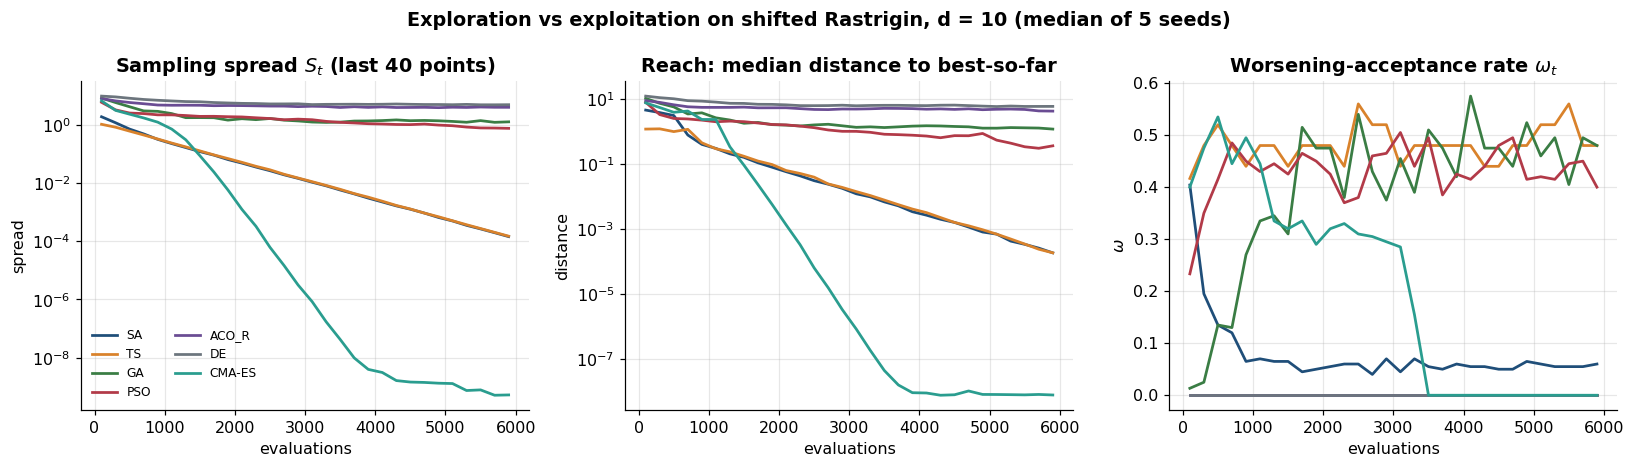

In [9]:
mid = 0.5 * (edges[1:] + edges[:-1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for a, M in metrics.items():
    for j, ax in enumerate(axes):
        ax.plot(mid, np.nanmedian(M[:, j], 0), label=a, lw=1.8)
axes[0].set(yscale="log", title="Sampling spread $S_t$ (last 40 points)", xlabel="evaluations", ylabel="spread")
axes[1].set(yscale="log", title="Reach: median distance to best-so-far", xlabel="evaluations", ylabel="distance")
axes[2].set(title=r"Worsening-acceptance rate $\omega_t$", xlabel="evaluations", ylabel=r"$\omega$")
axes[0].legend(ncol=2, fontsize=8)
fig.suptitle("Exploration vs exploitation on shifted Rastrigin, d = 10 (median of 5 seeds)", fontweight="bold")
plt.tight_layout(); savefig("w6_exploration_metrics.png"); plt.show()

**Reading the figure.** SA, TS and CMA-ES contract their sampling spread by orders of magnitude (by schedule for
SA/TS, by self-adaptation for CMA-ES): strong intensification. CMA-ES is non-elitist ($\omega_t\gt0$) until its
distribution has collapsed into one basin, after which all samples have (numerically) equal fitness. DE and ACO$_\mathbb{R}$
keep a large spread for the whole budget: their difference-vector / archive-spread step sizes shrink only as fast as
the population collapses, and their elitist memories ($\omega\equiv0$) are diversified only by *sampling*, never by
acceptance. GA and PSO let the working set get worse at roughly 40 % of the ranks every generation (generational
replacement; positions that move freely) while keeping an intermediate, slowly shrinking spread — they diversify
through acceptance and intensify through selection (GA) or attraction to $p_i, g$ (PSO). TS always moves to the best
admissible neighbour, even when it is worse (the audit in §2 recorded no forced moves), so it accepts a worsening in
about half of its moves; SA's annealed Metropolis rule in about 8 % of its iterations.

### Intensification/diversification balance: one knob, one U-curve
In PSO the inertia weight $w$ sets the balance directly: for fixed $c_1=c_2=1.49618$, a small $w$ damps velocities
(fast contraction, premature convergence), a large $w$ leaves the order-2 stable region (above the boundary computed
earlier, the swarm never contracts). The theory predicts an interior optimum.

w=0.2000: final f median  16.07 [IQR  12.43,  18.31], mean spread 0.320
w=0.4000: final f median  15.42 [IQR  12.93,  18.90], mean spread 0.421
w=0.5500: final f median   8.96 [IQR   6.97,  14.18], mean spread 0.667
w=0.6500: final f median  11.94 [IQR   8.21,  15.42], mean spread 0.951
w=0.7298: final f median   8.96 [IQR   6.74,  12.59], mean spread 1.539
w=0.8000: final f median  15.32 [IQR  11.98,  18.17], mean spread 2.126
w=0.9000: final f median  35.49 [IQR  27.08,  42.67], mean spread 3.387
w=1.0000: final f median  44.54 [IQR  35.05,  49.16], mean spread 4.310
[PASS] best inertia weight is interior (w = 0.55)


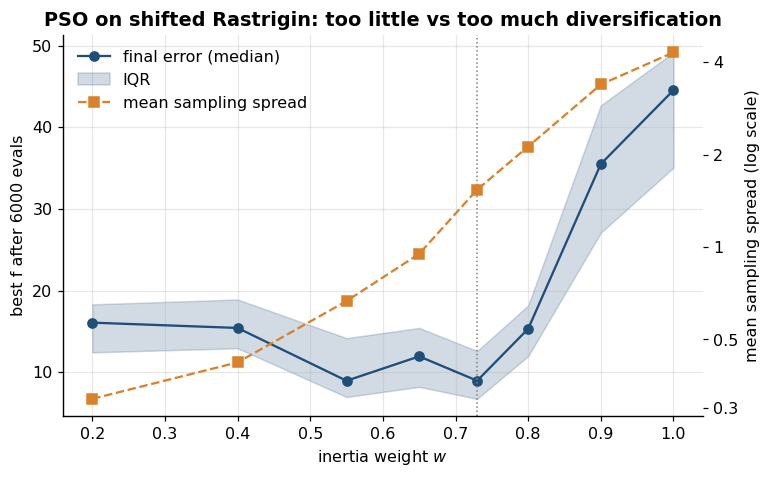

In [10]:
ws = np.array([0.2, 0.4, 0.55, 0.65, 0.7298, 0.8, 0.9, 1.0])
res_w, spread_w = [], []
for w in ws:
    F, S = [], []
    for s in range(10):
        rec = Recorder()
        F.append(optimize(PSO(d, ras.lower, ras.upper, B, np.random.default_rng(s), w=w), f_ras, B, callback=rec).best_f)
        S.append(np.mean(np.array(rec.rows)[:, 1]))
    res_w.append(np.percentile(F, [25, 50, 75])); spread_w.append(np.median(S))
res_w = np.array(res_w)
w_best = ws[np.argmin(res_w[:, 1])]
for w, r, s_ in zip(ws, res_w, spread_w):
    print(f"w={w:6.4f}: final f median {r[1]:6.2f} [IQR {r[0]:6.2f}, {r[2]:6.2f}], mean spread {s_:.3f}")
check_true(ws[0] < w_best < ws[-1], f"best inertia weight is interior (w = {w_best})")

fig, ax = plt.subplots()
ax.plot(ws, res_w[:, 1], "o-", color=PALETTE["blue"], label="final error (median)")
ax.fill_between(ws, res_w[:, 0], res_w[:, 2], alpha=0.2, color=PALETTE["blue"], label="IQR")
ax2 = ax.twinx(); ax2.plot(ws, spread_w, "s--", color=PALETTE["orange"], label="mean sampling spread")
ax2.set_yscale("log"); ax2.set_ylabel("mean sampling spread (log scale)"); ax2.grid(False)
from matplotlib.ticker import FixedLocator, NullLocator, FormatStrFormatter
ax2.yaxis.set_major_locator(FixedLocator([0.3, 0.5, 1, 2, 4])); ax2.yaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_major_formatter(FormatStrFormatter("%g"))
ax.axvline(0.7298, color="grey", ls=":", lw=1)
ax.set(xlabel="inertia weight $w$", ylabel="best f after 6000 evals",
       title="PSO on shifted Rastrigin: too little vs too much diversification")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper left")
savefig("w6_pso_inertia_ucurve.png"); plt.show()

## 4. The metaphor critique: harmony search *is* a $(\mu+1)$-ES

Sörensen (2015, *Metaheuristics — the metaphor exposed*, ITOR 22(1)) argued that a flood of "novel" nature-inspired
methods hide well-known mechanisms behind new vocabulary. Weyland (2010, IJAMC 1(2)) proved that **harmony search**
(Geem, Kim & Loganathan 2001) is a special case of the $(\mu+1)$ evolution strategy; Camacho-Villalón, Dorigo & Stützle
made the same point for intelligent water drops ($\approx$ ACO; *Swarm Intelligence* 2019) and for grey wolf, moth-flame,
whale, firefly, bat and antlion optimisers (ITOR, published online 2022).

**Harmony search in its own words.** A *harmony memory* HM of HMS harmonies. To *improvise* a new harmony, each
*musician* $j$ either (prob. HMCR) recalls a note from memory, $x_j = h_{r,j}$ with $r$ uniform, and then (prob. PAR)
*adjusts the pitch* $x_j \leftarrow x_j + \mathrm{bw}\cdot U(-1,1)$; or (prob. $1-$HMCR) plays a random note
$x_j\sim U(\ell,u)$. If the new harmony is better than the worst in HM, it replaces it.

**Translation.** The offspring distribution is a product over coordinates of

$$
P(x_j) = \mathrm{HMCR}\,(1-\mathrm{PAR})\,\frac{1}{\mu}\sum_{i=1}^{\mu}\delta_{h_{ij}}
+ \mathrm{HMCR}\,\mathrm{PAR}\,\frac{1}{\mu}\sum_{i=1}^{\mu} U[h_{ij}-\mathrm{bw},\,h_{ij}+\mathrm{bw}]
+ (1-\mathrm{HMCR})\,U[\ell,u],
$$

i.e. **global discrete (uniform) recombination** over $\mu=$HMS parents (Bäck 1996) followed by a coordinate-wise
mixture **mutation** (uniform creep w.p. HMCR·PAR, uniform reset w.p. $1-$HMCR), and "replace the worst if better" is
$(\mu+1)$ **plus-selection**. Nothing is new except the words. Below, the two are coded in their own vocabularies —
a musician-by-musician loop versus a vectorised ES — and fed the *same* random numbers: if the algebra is right the
trajectories coincide bit for bit.

In [11]:
def improvise(HM, r, lo, hi, HMCR, PAR, bw):
    """One new harmony, musician by musician (the metaphor's vocabulary)."""
    HMS, d = HM.shape
    recall, which, adjust, pitch, random_note = (r.random(d), r.integers(0, HMS, d), r.random(d),
                                                 r.uniform(-1, 1, d), r.uniform(lo, hi, d))
    new = np.empty(d)
    for musician in range(d):
        if recall[musician] < HMCR:                       # memory consideration
            new[musician] = HM[which[musician], musician]
            if adjust[musician] < PAR:                   # pitch adjustment
                new[musician] += bw * (hi - lo) * pitch[musician]
        else:                                            # random selection
            new[musician] = random_note[musician]
    return np.clip(new, lo, hi)

def harmony_search(f, d, lo, hi, iters, seed, HMS=10, HMCR=0.9, PAR=0.3, bw=0.05):
    """Harmony search (Geem et al. 2001), written in the metaphor's vocabulary."""
    r = np.random.default_rng(seed)
    HM = r.uniform(lo, hi, (HMS, d)); scores = f(HM); history = [scores.min()]
    for _ in range(iters):
        new = improvise(HM, r, lo, hi, HMCR, PAR, bw)
        worst = np.argmax(scores); s_new = f(new)
        if s_new < scores[worst]:
            HM[worst], scores[worst] = new, s_new
        history.append(scores.min())
    return np.array(history), HM

def mu_plus_one_es(f, d, lo, hi, iters, seed, mu=10, p_rec=0.9, p_creep=0.3, width=0.05):
    """(mu+1)-ES: global discrete recombination, creep/reset mutation, plus-selection."""
    r = np.random.default_rng(seed)
    P = r.uniform(lo, hi, (mu, d)); fP = f(P); history = [fP.min()]
    for _ in range(iters):
        u1, parents, u2, z, reset = r.random(d), r.integers(0, mu, d), r.random(d), r.uniform(-1, 1, d), r.uniform(lo, hi, d)
        child = P[parents, np.arange(d)]                                   # global discrete recombination
        child = child + ((u1 < p_rec) & (u2 < p_creep)) * width * (hi - lo) * z   # creep mutation
        child = np.where(u1 < p_rec, child, reset)                         # reset mutation
        child = np.clip(child, lo, hi)
        pool = np.vstack([P, child]); fpool = np.append(fP, f(child))
        keep = np.argsort(fpool, kind="stable")[:mu]                       # (mu + 1) plus-selection
        if mu not in keep:  # child rejected: memory unchanged (keeps order identical to HM)
            history.append(fP.min()); continue
        worst = np.argmax(fP); P[worst], fP[worst] = child, fpool[-1]
        history.append(fP.min())
    return np.array(history), P

traces_hs, traces_es = [], []
for s in range(5):
    h_hs, HM = harmony_search(f_ras, d, ras.lower, ras.upper, 5000, seed=s)
    h_es, P = mu_plus_one_es(f_ras, d, ras.lower, ras.upper, 5000, seed=s)
    traces_hs.append(h_hs); traces_es.append(h_es)
    check_true(np.array_equal(h_hs, h_es) and np.array_equal(np.sort(HM, 0), np.sort(P, 0)),
               f"seed {s}: harmony search and (mu+1)-ES trajectories identical (final f = {h_hs[-1]:.3f})")

# the translation formula, tested on the metaphor code itself: by the mixture above a coordinate of a new harmony is
# (a) copied verbatim from memory w.p. HMCR (1 - PAR) and (b) lies outside [min_i h_ij - bw', max_i h_ij + bw']
# (bw' = bw (u - l)) only through the uniform reset. With a memory concentrated in [-0.5, 0.5] on the box [-5, 5]:
r_ = np.random.default_rng(11); HMr = r_.uniform(-0.5, 0.5, (10, d)); lo_, hi_ = -5.0, 5.0
news = np.array([improvise(HMr, r_, lo_, hi_, 0.9, 0.3, 0.05) for _ in range(20000)])
verbatim = np.mean([np.isin(news[:, j], HMr[:, j]) for j in range(d)])
outside = np.mean(np.abs(news) > 0.5 + 0.05 * (hi_ - lo_))
p_out = (1 - 0.9) * (1 - 2 * 1.0 / (hi_ - lo_))               # a uniform reset on [-5, 5] lands outside [-1, 1] w.p. 8/10
for name_, got, exp in [("verbatim copy = HMCR (1 - PAR)", verbatim, 0.9 * 0.7), ("reset outside the memory hull = (1 - HMCR) 0.8", outside, p_out)]:
    check_close(got, exp, f"harmony search: Pr[{name_}]", atol=4 * np.sqrt(exp * (1 - exp) / news.size), rtol=0)

[PASS] seed 0: harmony search and (mu+1)-ES trajectories identical (final f = 3.461)


[PASS] seed 1: harmony search and (mu+1)-ES trajectories identical (final f = 7.295)


[PASS] seed 2: harmony search and (mu+1)-ES trajectories identical (final f = 9.928)


[PASS] seed 3: harmony search and (mu+1)-ES trajectories identical (final f = 3.928)


[PASS] seed 4: harmony search and (mu+1)-ES trajectories identical (final f = 6.397)


[PASS] harmony search: Pr[verbatim copy = HMCR (1 - PAR)]: got 0.63138, expected 0.63
[PASS] harmony search: Pr[reset outside the memory hull = (1 - HMCR) 0.8]: got 0.07936, expected 0.08


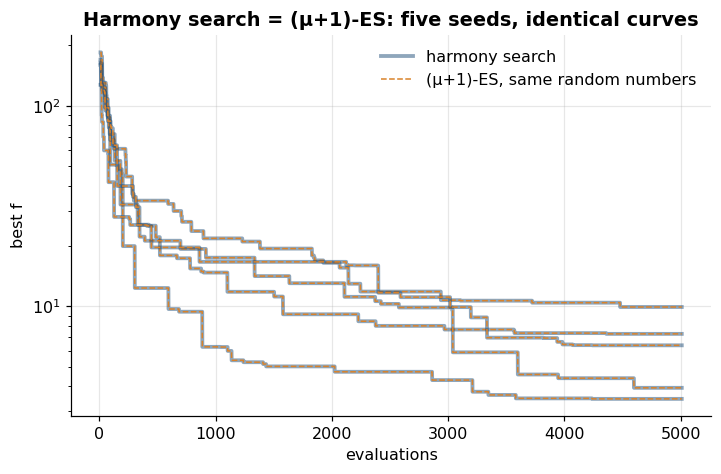

In [12]:
fig, ax = plt.subplots()
ev = np.arange(5001) + 10
for s in range(5):
    ax.plot(ev, traces_hs[s], color=PALETTE["blue"], lw=2.5, alpha=0.5, label="harmony search" if s == 0 else None)
    ax.plot(ev, traces_es[s], color=PALETTE["orange"], lw=1, ls="--", label="(μ+1)-ES, same random numbers" if s == 0 else None)
ax.set(yscale="log", xlabel="evaluations", ylabel="best f", title="Harmony search = (μ+1)-ES: five seeds, identical curves")
ax.legend(); savefig("w6_harmony_equals_es.png"); plt.show()

## 5. The centre-bias pitfall

Most textbook benchmarks (sphere, Rastrigin, Ackley, Griewank) have their optimum at the **origin**, the centre of the
box. An operator that contracts points multiplicatively towards $0$ is then an unfair "oracle". Kudela (2022,
*Nature Machine Intelligence* 4) showed that many recently published metaheuristics owe their benchmark success to such
a bias. We build a caricature, the *origin-pull optimiser* (OPO): candidates $x = r\odot x^{\ast} + 0.1\,\epsilon\,(a-x^{\ast})$
with $r\sim U(0,1)^d$, $a$ a random archive member and $\epsilon\sim\mathcal{N}(0,1)$, plus $(\mu+\lambda)$ truncation.
Nothing in it looks at the landscape to decide *where* to go; it just shrinks towards $0$.

**Protocol.** Compare OPO with PSO and DE at 5000 evaluations (d = 10, 8 seeds) on the original functions and on
the same functions with the optimum shifted to a random point $o$, $g(x) = f(x-o)$. An unbiased method should be
(statistically) unaffected by the shift.

In [13]:
class OPO(AskTell):
    """'Origin-pull optimiser': a deliberately centre-biased caricature."""
    name = "OPO"

    def __init__(self, d, lo, hi, budget, rng, n=20):
        super().__init__(d, lo, hi, budget, rng); self.n, self.P = n, None

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        g = self.P[np.argmin(self.fP)]
        A = self.P[self.rng.integers(0, self.n, self.n)]
        return self.clip(self.rng.random((self.n, self.d)) * g + 0.1 * (A - g) * self.rng.standard_normal((self.n, 1)))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy(); return
        P, fP = np.vstack([self.P, X]), np.concatenate([self.fP, y])
        o = np.argsort(fP)[: self.n]; self.P, self.fP = P[o], fP[o]

B_c, seeds_c = 5000, 8
bias = {}
for fn in ["rastrigin", "ackley", "griewank"]:
    b = BENCHMARKS[fn]
    o = np.random.default_rng(3).uniform(0.4 * b.lower, 0.4 * b.upper, d)
    for tag, f in [("origin", b.f), ("shifted", shifted_rotated(b.f, o, np.eye(d)))]:
        for A in [OPO, PSO, DE]:
            bias[fn, tag, A.name] = np.array([optimize(A(d, b.lower, b.upper, B_c, np.random.default_rng(s)), f, B_c).best_f
                                              for s in range(seeds_c)])
for fn in ["rastrigin", "ackley", "griewank"]:
    row = "  ".join(f"{a}: {np.median(bias[fn, 'origin', a]):8.2e} -> {np.median(bias[fn, 'shifted', a]):8.2e}" for a in ["OPO", "PSO", "DE"])
    print(f"{fn:9s} (origin -> shifted, median) {row}")
    check_true(np.median(bias[fn, "origin", "OPO"]) < min(np.median(bias[fn, "origin", "PSO"]), np.median(bias[fn, "origin", "DE"])),
               f"{fn}: OPO 'wins' when the optimum is at the origin")
    check_true(np.median(bias[fn, "shifted", "OPO"]) > max(np.median(bias[fn, "shifted", "PSO"]), np.median(bias[fn, "shifted", "DE"])),
               f"{fn}: OPO loses to both once the optimum is shifted")
    p_pso = stats.mannwhitneyu(bias[fn, "origin", "PSO"], bias[fn, "shifted", "PSO"]).pvalue
    p_opo = stats.mannwhitneyu(bias[fn, "origin", "OPO"], bias[fn, "shifted", "OPO"]).pvalue
    print(f"          Mann-Whitney origin vs shifted: OPO p = {p_opo:.1e}, PSO p = {p_pso:.2f}")

rastrigin (origin -> shifted, median) OPO: 0.00e+00 -> 6.31e+01  PSO: 7.50e+00 -> 9.01e+00  DE: 3.86e+01 -> 4.12e+01
[PASS] rastrigin: OPO 'wins' when the optimum is at the origin
[PASS] rastrigin: OPO loses to both once the optimum is shifted
          Mann-Whitney origin vs shifted: OPO p = 4.1e-04, PSO p = 0.51
ackley    (origin -> shifted, median) OPO: 4.44e-16 -> 1.54e+01  PSO: 9.27e-03 -> 7.20e-03  DE: 1.00e+00 -> 9.42e-01
[PASS] ackley: OPO 'wins' when the optimum is at the origin
[PASS] ackley: OPO loses to both once the optimum is shifted
          Mann-Whitney origin vs shifted: OPO p = 4.1e-04, PSO p = 0.72
griewank  (origin -> shifted, median) OPO: 0.00e+00 -> 3.25e+01  PSO: 1.18e-01 -> 1.43e-01  DE: 7.44e-01 -> 7.98e-01
[PASS] griewank: OPO 'wins' when the optimum is at the origin
[PASS] griewank: OPO loses to both once the optimum is shifted
          Mann-Whitney origin vs shifted: OPO p = 4.1e-04, PSO p = 0.72


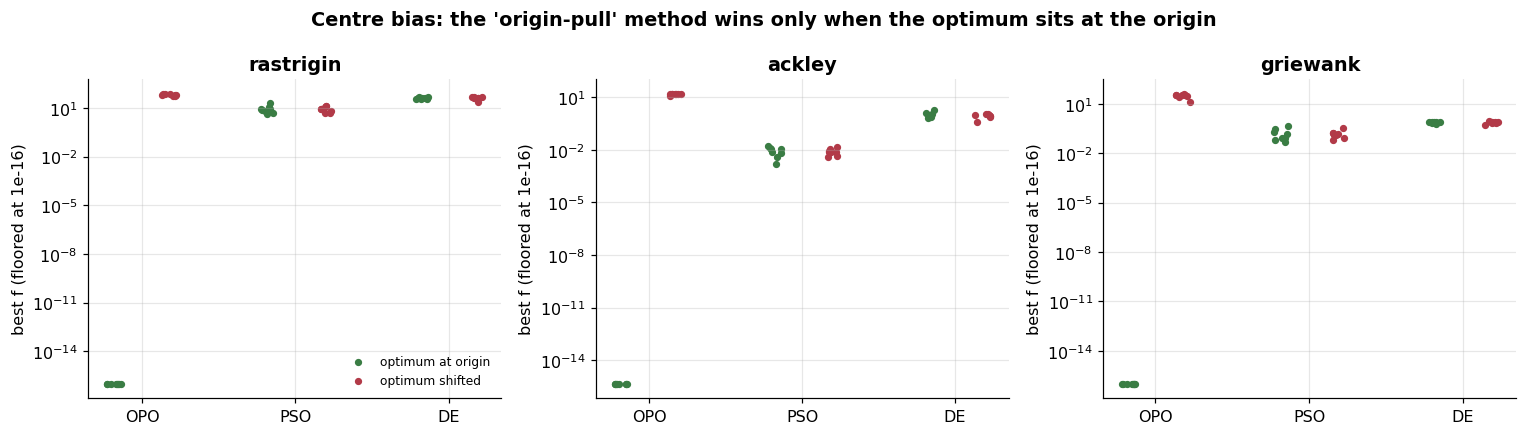

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, fn in zip(axes, ["rastrigin", "ackley", "griewank"]):
    for i, a in enumerate(["OPO", "PSO", "DE"]):
        for j, tag in enumerate(["origin", "shifted"]):
            v = np.maximum(bias[fn, tag, a], 1e-16)
            ax.scatter(np.full(seeds_c, i + 0.18 * (2 * j - 1)) + rng.uniform(-0.05, 0.05, seeds_c), v, s=14,
                       color=[PALETTE["green"], PALETTE["red"]][j], label=["optimum at origin", "optimum shifted"][j] if i == 0 else None)
    ax.set(yscale="log", xticks=[0, 1, 2], xticklabels=["OPO", "PSO", "DE"], title=fn, ylabel="best f (floored at 1e-16)")
axes[0].legend(fontsize=8)
fig.suptitle("Centre bias: the 'origin-pull' method wins only when the optimum sits at the origin", fontweight="bold")
plt.tight_layout(); savefig("w6_center_bias.png"); plt.show()

**Consequence for methodology.** Benchmark on shifted *and* rotated functions (utils `shifted_rotated`), as the CEC and
BBOB/COCO suites do; report results on both if a method claims invariance. A method whose performance changes with a
shift of the coordinate system is exploiting the *benchmark*, not the *problem*. PSO's and DE's differences between the
two settings are small and (typically) not significant, while OPO's are orders of magnitude.

**AI/ML connection.** The same framework describes hyperparameter optimisers (random search, TPE and CMA-ES in Optuna
are ask–tell samplers), neural-architecture search (regularised evolution is a steady-state GA with ageing) and
evolution strategies for RL policy search (Salimans et al. 2017): each is a memory, a sampling distribution and an
update rule. Centre bias is also a real risk there: search spaces are often defined around "default" values.

## Key takeaways
- Every metaheuristic in this course is a loop of **sample from $P(\cdot\mid M)$ → evaluate → select/update $M$**;
  one ask–tell loop with plug-ins runs all seven, and each plug-in's mechanism matches its theoretical prediction.
- The meaningful design axes are the **distribution family**, the **memory** and the **greediness of acceptance** —
  not the metaphor.
- Exploration/exploitation can be *measured*: sampling spread, reach around the incumbent and worsening-acceptance
  rate differ systematically across algorithms, and a single knob (PSO inertia) produces the predicted U-curve.
- Harmony search is exactly a $(\mu+1)$-ES with discrete recombination and creep/reset mutation: identical
  trajectories under common random numbers.
- Origin-centred benchmarks reward centre-biased operators; always shift (and rotate) test functions.

## Exercises
1. ★ Write the ask/tell pair for a $(1+1)$-EA on bit strings (standard bit mutation with rate $1/n$). Which row of the
   table in §1 does it belong to, and what is its worsening-acceptance rate $\omega$?
2. ★★ Prove that SBX with spread factor $\beta$ preserves the parents' midpoint and that
   $\lvert c_1-c_2\rvert=\beta\lvert p_1-p_2\rvert$. What does this imply for population diversity under crossover alone?
3. ★★ Derive the $3\times3$ second-moment matrix used in §2 for general $c_1\neq c_2$ and show that the stability
   condition depends on $c_1,c_2$ only through $\mathbb{E}[\varphi]$ and $\mathrm{Var}[\varphi]$.
4. ★★ Show that in the limit $T\to0$ (pass `T0` explicitly, so that the calibration walk is skipped) the SA plug-in
   reduces to a $(1+1)$-ES with a deterministic step-size schedule, and that TS with $k=1$ is a Gaussian random walk
   whatever $L$ is. Verify both numerically with the generic loop and common random numbers.
5. ★★★ Pick one of the algorithms analysed by Camacho-Villalón, Dorigo & Stützle (e.g. the grey wolf optimiser) and
   rewrite its update equations in the vocabulary of §1. Implement it as a plug-in and test it for centre bias as in §5.
6. ★★★ Design a *translation-invariance* test: run an algorithm on $f$ and on $f(\cdot-o)$ with the initial
   population shifted by $o$ and common random numbers. Which of the seven plug-ins produce identical trajectories
   (up to floating point), and why do the box constraints break invariance for some of them?